[-0.380000000000000 2.77555756156289e-17 0.380000000000001
 -0.0636000000000000 -0.00609999999999998 -0.0636000000000001]


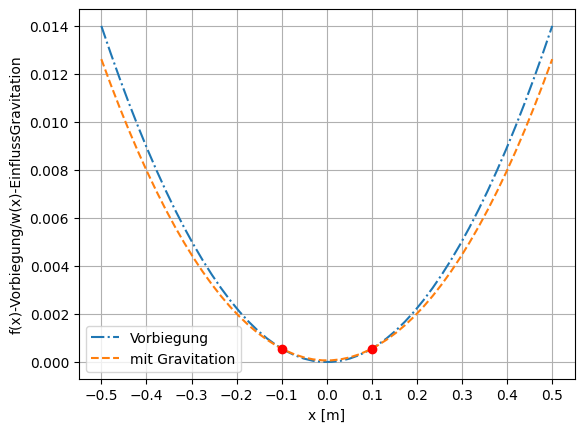

In [3]:
import matplotlib.pyplot as plt
from scipy.integrate import quad
import numpy as np
import sympy as sp
#from gleichungssystem_w import solve_constants,c1A,c2A,c1B,c2B,c1C,c2C

c1A, c2A = sp.symbols('c1A c2A')
c1B, c2B = sp.symbols('c1B c2B')
c1C, c2C = sp.symbols('c1C c2C')

def solve_constants(a,b,q,E,I):
    # Variablen
    #a, b, q, E, I, x = sp.symbols('a b q E I x')
    x = sp.symbols('x')

    # Durchbiegungsfunktionen
    wA = q/(24*E*I) * ((a+x)**4 + c1A*x + c2A)
    wB = q/(24*E*I) * (x**4 + 12*a**2*x**2 - 24*b*x**2 + c1B*x + c2B)
    wC = q/(24*E*I) * ((a-x)**4 + c1C*x + c2C)

    # Ableitungen
    wA_p = sp.diff(wA, x)
    wB_p = sp.diff(wB, x)
    wC_p = sp.diff(wC, x)

    # Gleichungen
    eq1 = sp.Eq(wA.subs(x, -b), 0)          # w(-b)=0
    eq2 = sp.Eq(wC.subs(x,  b), 0)          # w(b)=0

    eq3 = sp.Eq(wA.subs(x, -b), wB.subs(x, -b))   # w stetig bei -b
    eq4 = sp.Eq(wA_p.subs(x, -b), wB_p.subs(x, -b)) # w' stetig bei -b

    eq5 = sp.Eq(wB.subs(x,  b), wC.subs(x,  b))   # w stetig bei b
    eq6 = sp.Eq(wB_p.subs(x,  b), wC_p.subs(x,  b)) # w' stetig bei b

    # Gleichungssystem lösen
    solution = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6],
                        [c1A, c2A, c1B, c2B, c1C, c2C])

    #print(solution)
    return solution


a = 0.5 #m
length = 2*a #m

#Auflagerorte
b = 0.1
x1 = -b
x2 = b

#Maße von Querschnitt
breite=0.4 #m
hoehe=0.004 #m
A = breite * hoehe #Querschnitt

roh = 2500 #kg/m**3 - Dichte
g = 9.81 #m/s² - Gravitation
E = 70e9 #N/m² - Elastizitätsmodul
I_y = hoehe**3*breite/12 # m^4 - Flächenträgheitsmoment
q_0 = roh * A * g #N/m - Streckenbelastung


def f(x):
    return 0.014*4*x**2

#print(solution[c1A])
c_list = [c1A,c1B,c1C,c2A,c2B,c2C]
solution = solve_constants(a,b,q_0,E,I_y)


c_results = np.zeros(6,dtype=object)
for i,c in enumerate(c_list):
    c_results[i] = solution[c]

print(c_results)

def omega(x):
    # links von Auflagern
    if x < x1:
        return (-q_0/(24*E*I_y)) * ((a+x)**4 + c_results[0]*x + c_results[3])
        
    # zwischen Auflagern
    elif x < x2:
        return (-q_0/(24*E*I_y)) * (x**4 + 12*a**2*x**2 + 24*x1*x**2 + c_results[1]*x + c_results[4])
    
    # rechts von Auflagern
    else:
        return (-q_0/(24*E*I_y)) * ((a-x)**4 + c_results[2]*x + c_results[5])


#plotten von f und f+omega

x_vals = np.linspace(-a,a,50)
f_vals = np.array([f(x) for x in x_vals])
omega_vals = np.array([omega(x) for x in x_vals])

w_vals = f_vals + omega_vals

plt.plot(x_vals,f_vals,label="Vorbiegung",linestyle='dashdot')
plt.plot(x_vals,w_vals,label="mit Gravitation",linestyle="dashed")
plt.xlabel("x [m]")
plt.ylabel("f(x)-Vorbiegung/w(x)-EinflussGravitation")
plt.legend()
plt.plot(-b,f(-b),'ro') 
plt.plot(b,f(b),'ro') 

plt.grid(True)

plt.locator_params(axis='x', nbins=20)  # 20 Ticks auf x-Achse
plt.locator_params(axis='y', nbins=15)  # 15 Ticks auf y-Achse

# plt.grid(True, which='major', linestyle='-', linewidth=0.3, color='black')

# # Feineres Grid für Nebenticks
# plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray')

# # Nebenticks aktivieren
# plt.minorticks_on()
plt.show()